In [49]:
# This script makes the time series of February sea ice extent in the Southern Hemsiphere from the OSISAF sea ice index data.

# First we download the file https://thredds.met.no/thredds/fileServer/osisaf/met.no/ice/index/v2p3/sh/osisaf_sh_sie_monthly.nc with requests

import requests
url = "https://thredds.met.no/thredds/fileServer/osisaf/met.no/ice/index/v2p3/sh/osisaf_sh_sie_monthly.nc"
response = requests.get(url)
with open("osisaf_sh_sie_monthly.nc", "wb") as f:
    f.write(response.content)

ds = xr.open_dataset("osisaf_sh_sie_monthly.nc")

# Sub-select to 1980, this Year
yearb = 1980
yeare = 2026
ds_feb = ds.sel(time=(ds.time.dt.month == 2) & (ds.time.dt.year >= yearb) & (ds.time.dt.year <= yeare))


# We fit a linear trend to the data.

# Trend fit
import numpy as np



time = np.arange(yearb, yeare + 1)


sie = ds_feb.sie.values


a = np.polyfit(time, sie, 1)

fit = a[0] * time + a[1]
res = sie - fit
std = np.nanstd(res)


[(2.2310267857142856, 2023), (2.3949776785714287, 2017), (2.414601293103449, 2024), (2.4699330357142855, 2025), (2.4839955357142856, 2018), (2.5114955357142854, 2022), (2.676875, 1997), (2.721450892857142, 2011), (2.8005133928571424, 2006), (2.8403794642857148, 1993), (2.8452901785714286, 2019), (2.9866594827586206, 1984), (2.99296875, 1985), (3.0466163793103447, 2016), (3.0717672413793093, 1992), (3.091293103448275, 1988), (3.120848214285714, 2005), (3.123863146551724, 1980), (3.1646875000000003, 2007), (3.1744698660714286, 1981), (3.198771551724138, 2000), (3.2029464285714284, 1990), (3.2085560344827586, 2020), (3.2117857142857145, 1989), (3.221004464285714, 1998), (3.2426177500000004, 2026), (3.2963392857142857, 2002), (3.3205357142857137, 1999), (3.3305245535714287, 2021), (3.342112068965517, 1996), (3.3571651785714285, 2009), (3.3605580357142855, 2010), (3.390747767857143, 1983), (3.43609375, 1982), (3.437834821428571, 1991), (3.445491071428571, 1994), (3.5056138392857137, 1987), 

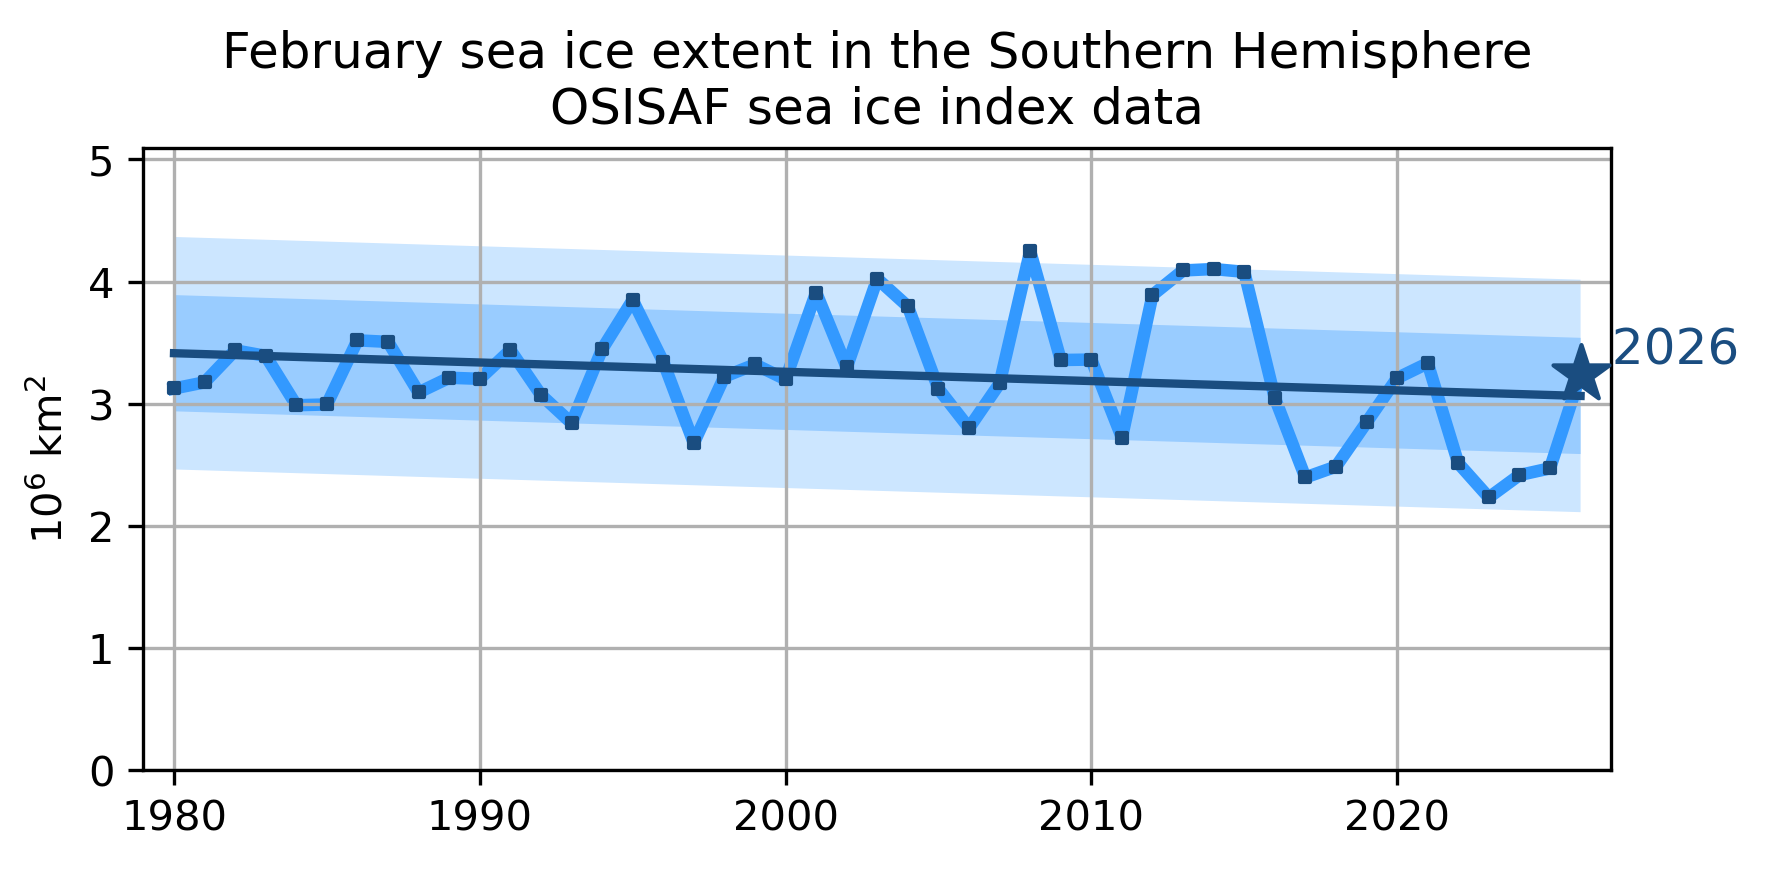

In [56]:


# Figure
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize = (6, 3), dpi = 300)

ax.plot(time, sie, color = [0.2, 0.6, 1.0], lw = 3, ls = "-", zorder = -1)
ax.scatter(time, sie, 5, color = [0.1, 0.3, 0.5], marker = "s")
ax.plot(time, fit, color = [0.1, 0.3, 0.5], lw = 2, linestyle = "-")
ax.scatter(time[-1], sie[-1], 200, marker = '*', color = [0.1, 0.3, 0.5],
           zorder = 1000)
ax.fill_between(time,  fit - 2 * std, fit + 2 * std, linewidth = 0,
                edgecolor = None, facecolor = [0.8, 0.9, 1.0], zorder = -3)
ax.fill_between(time,  fit - 1 * std, fit + 1 * std, linewidth = 0,
                edgecolor = None, facecolor = [0.6, 0.8, 1.0], zorder = -2)



ax.set_ylim(0.0, 1.2 * np.nanmax(sie))
ax.set_xlim(time[0] - 1, time[-1] + 1)
ax.set_axisbelow(True)
ax.set_ylabel("10$^6$ km$^2$")
ax.set_title("February sea ice extent in the Southern Hemisphere\nOSISAF sea ice index data")

# Add the last year near the star
ax.text(time[-1] + 0.5, sie[-1], " " + str(time[-1]), va = "bottom", ha = "left", fontsize = 12, color = [0.1, 0.3, 0.5])

ax.grid()

# Sorted data
sorted_data = [x for x in sorted(zip(sie,time))]
print(sorted_data)

plt.tight_layout()
figName = "../figs/figTimeSeries.png"
plt.savefig(figName, dpi = 400)
print(figName + " printed")
